<a href="https://colab.research.google.com/github/alansiny/INTERSHIP-AI-ML/blob/main/image_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image

In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/archive.zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 2074


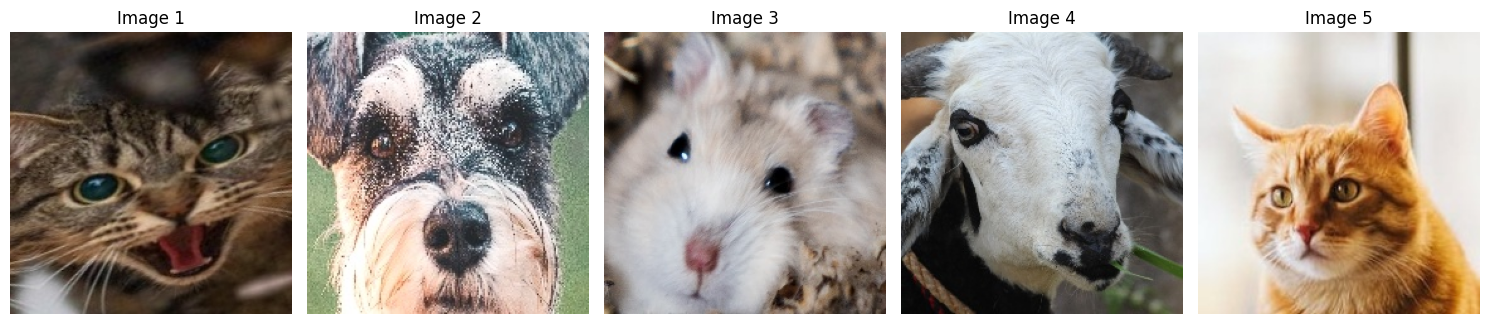

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    # Convert BGR to RGB (OpenCV loads images in BGR format)
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

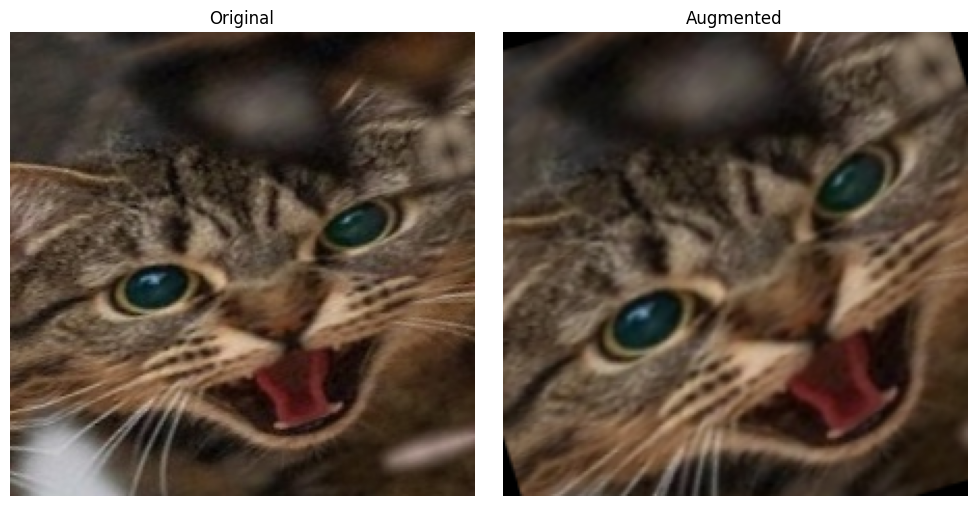

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Original image
original = cv2.resize(images[0], (224, 224))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Augmented image
augmented = preprocess_image(
    images[0],
    size=(224, 224),
    color_mode='rgb',
    normalize=False,   # Keep pixel values in 0-255 for display
    augment=True
)

# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented)
plt.title("Augmented")
plt.axis('off')

plt.tight_layout()
plt.show()

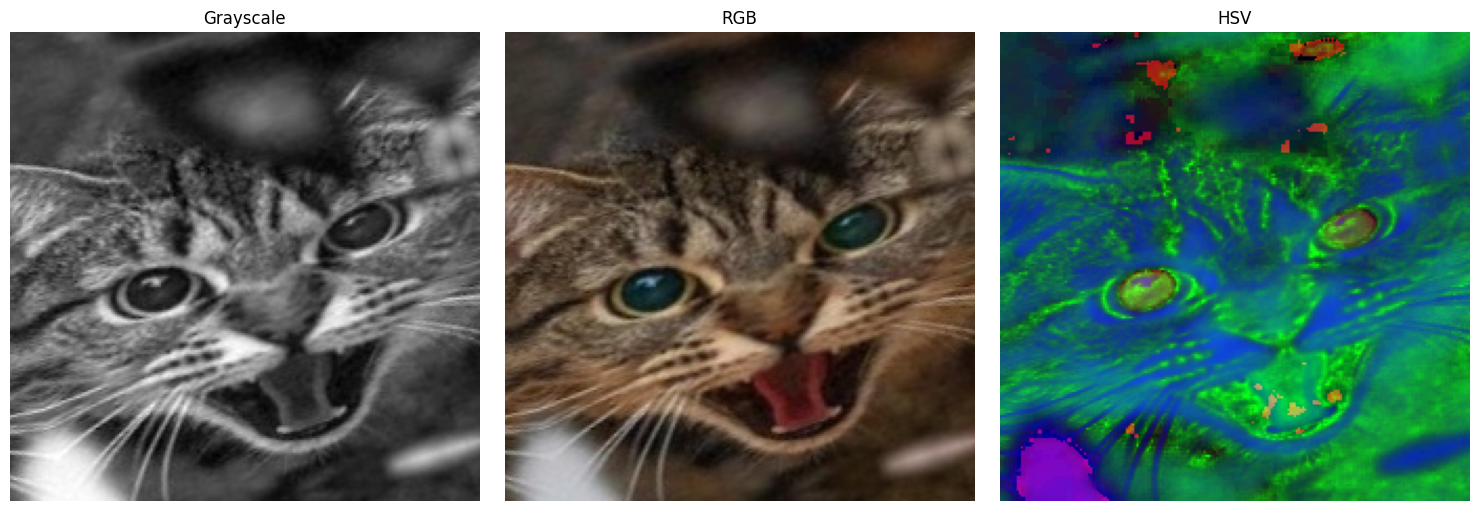

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Grayscale
plt.subplot(1,3,1)
plt.imshow(gray_images[0], cmap='gray')
plt.title("Grayscale")
plt.axis('off')

# RGB
plt.subplot(1,3,2)
plt.imshow(rgb_images[0])
plt.title("RGB")
plt.axis('off')

# HSV
plt.subplot(1,3,3)
plt.imshow(hsv_images[0])
plt.title("HSV")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import random

def preprocess_image(img,
                     size=(224, 224),
                     color_mode='rgb',
                     normalize=True,
                     augment=False):

    # Resize
    img = cv2.resize(img, size)

    if augment:

        # Random Rotation
        angle = random.uniform(-20, 20)
        h, w = img.shape[:2]

        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        img = cv2.warpAffine(img, M, (w, h))

        # Random Horizontal Flip
        if random.random() > 0.5:
            img = cv2.flip(img, 1)

        # Random Zoom
        zoom_factor = random.uniform(1.0, 1.2)

        new_w = int(w / zoom_factor)
        new_h = int(h / zoom_factor)

        x = (w - new_w) // 2
        y = (h - new_h) // 2

        img = img[y:y+new_h, x:x+new_w]
        img = cv2.resize(img, (w, h))

        # Brightness Adjustment
        brightness = random.uniform(0.7, 1.3)

        img = np.clip(img * brightness, 0, 255).astype(np.uint8)

    # Color Conversion
    if color_mode.lower() == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    elif color_mode.lower() == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    elif color_mode.lower() == 'hsv':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Normalization
    if normalize:
        img = img.astype(np.float32) / 255.0

    return img